# Five Product Regime Experiments

This notebook builds **5 representative experiments** using products with different sales patterns:

- high demand
- transition / erratic demand
- lumpy demand
- intermittent demand
- ultra-sparse intermittent demand

For each product, the notebook shows:

1. the actual series vs the compared models
2. a table below the chart with:
   - all evaluated models
   - which model was selected for that case
   - why it was considered / why it was selected
   - detected regime
   - MAE and RMSE


In [1]:
import importlib
import subprocess
import sys

print('Notebook Python:', sys.executable)

required = ['numpy', 'pandas', 'statsmodels', 'scipy']
missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f'OK {pkg}')
    except ModuleNotFoundError:
        missing.append(pkg)

if missing:
    print('Installing missing packages in current kernel...', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
    print('Installation complete. Restart the kernel if needed.')
else:
    print('All required packages are available in the current kernel.')


Notebook Python: c:\Users\braya\AppData\Local\Programs\Python\Python311\python.exe
OK numpy
OK pandas
OK matplotlib
OK statsmodels
OK scipy
All required packages are available in the current kernel.


In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except Exception as e:
    print('Matplotlib disabled:', e)
    MATPLOTLIB_AVAILABLE = False
    plt = None
from IPython.display import display
from scipy.signal import find_peaks

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for _ in range(8):
        if (cur / 'src').exists() and (cur / 'reports').exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return start.resolve()

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print('Repo root:', REPO_ROOT)


Repo root: C:\Users\braya\Documents\Research\aurex-demand-forecasting-main


In [3]:
from src.experiments.run_cross_market_peak_comparison import (
    _load_amazon_selected,
    _load_favorita_selected,
    _load_m5_selected,
)
from src.models.croston_model import CrostonSBAModel
from src.models.hurdle_model import HurdleModel
from src.models.regime_forecast_engine import RegimeForecastEngine
from src.models.sarimax_model import SARIMAXModel
from src.models.tsb_model import TSBModel, sbc_classify

print('Imports OK')


Imports OK


## Case Configuration

These 5 cases cover clearly different scenarios for evaluating both the selector and the base models.

In [4]:

AMAZON_FILE = 'Health_and_Household.jsonl'
AMAZON_MAX_ROWS = 100_000
TEST_DAYS = 365

smooth_case = {
    'dataset': 'M5_WALMART',
    'series_id': 'FOODS_3_090_CA_3_validation',
    'semantic_product': 'Grocery item - smooth stable demand',
    'expected_regime': 'smooth',
    'target_story': 'High-frequency grocery product with consistent weekly pattern. SARIMAX is the correct model.',
    'use_weekly_tsb': False,
}

transition_hardcoded = {
    'dataset': 'M5_WALMART',
    'series_id': 'HOUSEHOLD_2_108_WI_1_validation',
    'zero_rate_expected': '~0.50',
}

m5_sales_path = REPO_ROOT / 'data' / 'raw' / 'm5' / 'sales_train_validation.csv'
m5_id_lookup = set(pd.read_csv(m5_sales_path, usecols=['id'])['id'].tolist())
if smooth_case['series_id'] not in m5_id_lookup:
    raise RuntimeError('Smooth fallback scan is not needed in this repo because FOODS_3_090_CA_3_validation exists.')

print('Smooth case selected:', smooth_case['series_id'])
print('Transition reference reserved for extensions:', transition_hardcoded['series_id'])

experiment_cases = [
    {
        'dataset': 'FAVORITA',
        'series_id': 'item_268443',
        'semantic_product': 'Cleaning product - high demand / dense sales',
        'expected_regime': 'high-demand',
        'target_story': 'Dense sales with relatively stable volume.',
        'use_weekly_tsb': False,
    },
    {
        'dataset': 'FAVORITA',
        'series_id': 'item_789224',
        'semantic_product': 'Cleaning product - erratic transition case',
        'expected_regime': 'erratic',
        'target_story': 'Product still sells often, but with more variability.',
        'use_weekly_tsb': False,
    },
    {
        'dataset': 'M5_WALMART',
        'series_id': 'HOUSEHOLD_1_187_WI_1_validation',
        'semantic_product': 'Household retail - lumpy / zero-heavy',
        'expected_regime': 'lumpy',
        'target_story': 'Very sparse demand with strong zero concentration.',
        'use_weekly_tsb': False,
    },
    {
        'dataset': 'AMAZON_2023',
        'series_id': 'B0BZTL57BP',
        'semantic_product': 'Household hygiene - intermittent demand',
        'expected_regime': 'intermittent',
        'target_story': 'Classic intermittent product with long zero runs and low non-zero variance.',
        'use_weekly_tsb': True,
    },
    {
        'dataset': 'AMAZON_2023',
        'series_id': 'B0BR4W8TBH',
        'semantic_product': 'Personal care - ultra sparse intermittent demand',
        'expected_regime': 'ultra-sparse intermittent',
        'target_story': 'Extreme zero-heavy product where weekly TSB is especially relevant.',
        'use_weekly_tsb': True,
    },
    smooth_case,
]

pd.DataFrame(experiment_cases)[['dataset', 'series_id', 'expected_regime', 'semantic_product']]


Smooth case selected: FOODS_3_090_CA_3_validation
Transition reference reserved for extensions: HOUSEHOLD_2_108_WI_1_validation


,dataset,series_id,expected_regime,semantic_product
0,FAVORITA,item_268443,high-demand,Cleaning product - high demand / dense sales
1,FAVORITA,item_789224,erratic,Cleaning product - erratic transition case
2,M5_WALMART,HOUSEHOLD_1_187_WI_1_validation,lumpy,Household retail - lumpy / zero-heavy
3,AMAZON_2023,B0BZTL57BP,intermittent,Household hygiene - intermittent demand
4,AMAZON_2023,B0BR4W8TBH,ultra-sparse intermittent,Personal care - ultra sparse intermittent demand
5,M5_WALMART,FOODS_3_090_CA_3_validation,smooth,Grocery item - smooth stable demand


In [5]:
m5_ids = [c['series_id'] for c in experiment_cases if c['dataset'] == 'M5_WALMART']
fav_ids = [c['series_id'] for c in experiment_cases if c['dataset'] == 'FAVORITA']
amz_ids = [c['series_id'] for c in experiment_cases if c['dataset'] == 'AMAZON_2023']

series_map_by_ds = {
    'M5_WALMART': _load_m5_selected(str(REPO_ROOT / 'data' / 'raw' / 'm5'), m5_ids),
    'FAVORITA': _load_favorita_selected(str(REPO_ROOT / 'data' / 'raw' / 'favorita'), fav_ids, store_nbr=1),
    'AMAZON_2023': _load_amazon_selected(
        str(REPO_ROOT / 'data' / 'raw' / 'amazon_2023' / 'review_categories'),
        AMAZON_FILE,
        amz_ids,
        max_rows=AMAZON_MAX_ROWS,
    ),
}

{k: list(v.keys()) for k, v in series_map_by_ds.items()}


{'M5_WALMART': ['FOODS_3_090_CA_3_validation',
  'HOUSEHOLD_1_187_WI_1_validation'],
 'FAVORITA': ['item_268443', 'item_789224'],
 'AMAZON_2023': ['B0BZTL57BP', 'B0BR4W8TBH']}

## Utility Functions

In [6]:

def train_test_split_ts(df, test_days=365):
    # Keep the latest block as test so the evaluation stays time-aware.
    df = df.sort_values('date').reset_index(drop=True)
    if len(df) <= test_days + 30:
        test_days = max(30, int(len(df) * 0.2))
    train = df.iloc[:-test_days].copy()
    test = df.iloc[-test_days:].copy()
    return train, test


def build_features(df):
    # Build the shared feature set used by SARIMAX and HURDLE.
    out = df.copy().sort_values('date').reset_index(drop=True)
    out['date'] = pd.to_datetime(out['date'])
    if 'price' not in out.columns:
        out['price'] = np.nan
    out['price'] = out['price'].ffill().bfill().fillna(0.0)

    out['dow'] = out['date'].dt.dayofweek
    out['month'] = out['date'].dt.month
    out['is_weekend'] = (out['dow'] >= 5).astype(int)

    out['lag_1'] = out['sales'].shift(1)
    out['lag_7'] = out['sales'].shift(7)
    out['lag_14'] = out['sales'].shift(14)
    out['lag_28'] = out['sales'].shift(28)

    out['ma_7'] = out['sales'].rolling(7, min_periods=1).mean()
    out['ma_14'] = out['sales'].rolling(14, min_periods=1).mean()
    out['ma_30'] = out['sales'].rolling(30, min_periods=1).mean()
    out['std_7'] = out['sales'].rolling(7, min_periods=1).std().fillna(0)

    out['days_since_sale'] = (out['sales'] == 0).astype(int).groupby((out['sales'] > 0).cumsum()).cumsum()
    out['sold_yesterday'] = (out['lag_1'] > 0).astype(int)
    out['trend_7'] = (out['ma_7'] - out['ma_7'].shift(7)).fillna(0)

    feature_cols = [
        'price', 'dow', 'month', 'is_weekend',
        'lag_1', 'lag_7', 'lag_14', 'lag_28',
        'ma_7', 'ma_14', 'ma_30', 'std_7',
        'days_since_sale', 'sold_yesterday', 'trend_7',
    ]

    out[feature_cols] = out[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return out, feature_cols


def compute_stats(y):
    # Structural diagnostics used for regime interpretation.
    y = np.asarray(y, dtype=float)
    nonzero = y[y > 0]
    return {
        'mean_demand': float(np.mean(y)) if len(y) else np.nan,
        'std_demand': float(np.std(y)) if len(y) else np.nan,
        'zero_rate': float((y == 0).mean()) if len(y) else np.nan,
        'ADI': float(len(y) / max(len(nonzero), 1)) if len(y) else np.nan,
        'CV2': float((np.std(nonzero) / max(np.mean(nonzero), 1e-6)) ** 2) if len(nonzero) > 1 else np.nan,
    }


def max_zero_run(y):
    y = np.asarray(y, dtype=float)
    longest = 0
    current = 0
    for value in y:
        if value == 0:
            current += 1
            longest = max(longest, current)
        else:
            current = 0
    return int(longest)


def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def peak_detection_rate(y_true, y_pred, window=3):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    prominence = max(0.2 * (y_true.max() - y_true.min()), 1e-6)
    true_peaks, _ = find_peaks(y_true, prominence=prominence)
    pred_peaks, _ = find_peaks(y_pred, prominence=prominence * 0.5)
    if len(true_peaks) == 0:
        return np.nan
    detected = sum(any(abs(tp - pp) <= window for pp in pred_peaks) for tp in true_peaks)
    return detected / len(true_peaks)


def variance_ratio(y_true, y_pred):
    sigma_t = float(np.std(y_true))
    sigma_p = float(np.std(y_pred))
    if sigma_t < 1e-9:
        return np.nan
    return sigma_p / sigma_t


def count_real_peaks(y_true):
    y_true = np.asarray(y_true, dtype=float)
    prominence = max(0.2 * (y_true.max() - y_true.min()), 1e-6)
    peaks, _ = find_peaks(y_true, prominence=prominence)
    return int(len(peaks))


def rank_models_for_selection(metrics_df, y_true, zero_rate):
    # Use behavioral guardrails first, then MAE/RMSE only as tie-breakers.
    ranked = metrics_df.copy()
    if count_real_peaks(y_true) > 0:
        peak_mask = ranked['pdr'].fillna(0.0) > 0.0
        if peak_mask.any():
            ranked = ranked[peak_mask].copy()

    if zero_rate >= 0.30:
        vr_mask = ranked['vr'].notna() & (ranked['vr'] >= 0.3) & (ranked['vr'] <= 3.0)
        if vr_mask.any():
            ranked = ranked[vr_mask].copy()

    ranked['pdr_penalty'] = 1.0 - ranked['pdr'].fillna(0.0)
    ranked['vr_distance'] = np.abs(ranked['vr'].fillna(1.0) - 1.0)
    return ranked.sort_values(['pdr_penalty', 'vr_distance', 'mae', 'rmse']).reset_index(drop=True)


def select_best_observed_model(metrics_df, y_true, zero_rate):
    ranked = rank_models_for_selection(metrics_df, y_true, zero_rate)
    return ranked.iloc[0]['model']


def model_purpose(model_name):
    if model_name == 'SARIMAX':
        return 'Baseline for dense or relatively stable demand with temporal structure.'
    if model_name == 'HURDLE':
        return 'Separates sale occurrence from sale size; useful for zero-heavy or erratic demand.'
    if model_name == 'CROSTON_SBA':
        return 'Classic intermittent-demand baseline using Croston with SBA bias correction.'
    if model_name == 'TSB':
        return 'Specialized model for intermittent demand with long zero runs.'
    return ''


def selection_reason_text(reason, model_name):
    mapping = {
        'hard_zero_rate_guardrail_sarimax': 'The product is in the smooth zero-rate zone (<0.30), so the paper guardrail routes it directly to SARIMAX.',
        'intermittent_tsb_domain': 'The series falls in the intermittent SBC domain, so TSB is the natural candidate.',
        'intermittent_ultra_sparse_weekly_tsb': 'The series is ultra-sparse, so weekly TSB is used to stabilize occurrence probability.',
        'lumpy_hurdle_domain': 'The series is lumpy, so HURDLE is preferred for zero/non-zero occurrence plus variable size.',
        'lumpy_series_guardrail': 'The series is lumpy, so SARIMAX is avoided by a structural guardrail.',
        'high_zero_rate_guardrail': 'The series has too many zeros, so HURDLE is prioritized.',
        'high_dispersion_guardrail': 'The combination of zeros and high dispersion favors HURDLE.',
        'rolling_validation_override': f'{model_name} was selected because it performed better in rolling validation.',
        'models_close_keep_regime_prior': f'The models were very close, so the regime prior was kept and {model_name} was chosen.',
        'sarimax_exploded_fallback_hurdle': 'SARIMAX produced an unstable forecast and the system fell back to HURDLE.',
        'short_series': f'The series is too short for robust validation, so the structural decision toward {model_name} was kept.',
        'no_valid_rolling_splits': f'There were not enough valid rolling splits, so the structural decision toward {model_name} was kept.',
        'transitional_zero_rate_blend': 'The product is in the transitional zero-rate zone, so the engine blended SARIMAX and HURDLE.',
    }
    return mapping.get(reason, f'{model_name} was selected by the regime engine and its guardrails.')


def observed_reason_text(best_model, metrics_df):
    row = metrics_df.set_index('model').loc[best_model]
    return (
        f"It is marked as the best observed model because it passed the behavioral guardrails "
        f"and ranked highest on the PDR+VR+MAE composite score "
        f"(MAE={row['mae']:.4f}, RMSE={row['rmse']:.4f}, PDR={row['pdr']:.3f}, VR={row['vr']:.3f})."
    )


def regime_threshold_text(stats, sbc_regime, zero_run):
    # Show the observed diagnostics and the decision thresholds directly on the chart.
    zero_rate = stats['zero_rate']
    adi = stats['ADI']
    cv2 = stats['CV2']
    lines = [
        f"Observed: zero_rate={zero_rate:.3f}, ADI={adi:.2f}, CV2={cv2:.3f}, max_zero_run={zero_run}",
        'Rules:',
        '  smooth: ADI <= 1.32 and CV2 < 0.49',
        '  erratic: ADI <= 1.32 and CV2 >= 0.49',
        '  intermittent: ADI > 1.32 and CV2 < 0.49',
        '  lumpy: ADI > 1.32 and CV2 >= 0.49',
        '  ultra-sparse flag: zero_rate >= 0.80 or max_zero_run >= 28',
        f'Detected regime now: {sbc_regime}',
    ]
    return '\n'.join(lines)


## Experiment Runner

In [7]:

def run_models_for_case(df, case):
    # Prepare the time-aware split and the shared feature matrix.
    feat_df, feature_cols = build_features(df)
    train_df, test_df = train_test_split_ts(feat_df, test_days=TEST_DAYS)

    y_train = train_df['sales'].astype(float).values
    y_test = test_df['sales'].astype(float).values
    X_train = train_df[feature_cols].astype(float).values
    X_test = test_df[feature_cols].astype(float).values

    outputs = {}

    # Run the three baseline models we want to compare side by side.
    sarimax_model = SARIMAXModel().fit(y_train, X_train)
    sarimax_pred, _, _ = sarimax_model.forecast(len(y_test), X_test)
    outputs['SARIMAX'] = sarimax_pred

    hurdle_model = HurdleModel().fit(X_train, y_train)
    hurdle_pred, _, _ = hurdle_model.forecast(X_test, X_train, y_train)
    outputs['HURDLE'] = hurdle_pred

    croston_model = CrostonSBAModel(use_weekly=case.get('use_weekly_tsb', False)).fit(y_train)
    croston_pred, _, _ = croston_model.forecast(len(y_test))
    outputs['CROSTON_SBA'] = croston_pred

    tsb_model = TSBModel(use_weekly=case.get('use_weekly_tsb', False), warn_if_not_tsb_domain=True)
    tsb_model.fit(y_train)
    tsb_pred, _, _ = tsb_model.forecast(len(y_test))
    outputs['TSB'] = tsb_pred

    # Run the regime engine separately so we can compare its recommendation
    # against the actual best observed model in this experiment.
    engine = RegimeForecastEngine()
    engine_pred, _, _, engine_model_name = engine.run(y_train, X_train, y_test, X_test)
    engine_selected_model = engine_model_name.replace('Regime-', '').replace('-Weekly', '')
    if engine_selected_model == 'CrostonSBA':
        engine_selected_model = 'CROSTON_SBA'

    stats = compute_stats(y_train)
    sbc = sbc_classify(y_train)

    # Compute error metrics for every candidate model.
    metrics_rows = []
    for model_name, y_pred in outputs.items():
        metrics_rows.append({
            'model': model_name,
            'mae': mae(y_test, y_pred),
            'rmse': rmse(y_test, y_pred),
            'pdr': peak_detection_rate(y_test, y_pred),
            'vr': variance_ratio(y_test, y_pred),
        })

    metrics_df = pd.DataFrame(metrics_rows).reset_index(drop=True)
    ranked_metrics_df = rank_models_for_selection(metrics_df, y_test, stats['zero_rate'])
    best_observed_model = ranked_metrics_df.iloc[0]['model']
    metrics_df['selection_rank'] = metrics_df['model'].map({name: i for i, name in enumerate(ranked_metrics_df['model'].tolist())})
    metrics_df = metrics_df.sort_values(['selection_rank', 'mae', 'rmse']).reset_index(drop=True)

    # Build the comparison table shown below each chart.
    comparison_rows = []
    for _, row in metrics_df.iterrows():
        model_name = row['model']
        is_engine_selected = model_name == engine_selected_model
        is_best_observed = model_name == best_observed_model
        comparison_rows.append({
            'model': model_name,
            'included_in_plot': 'Yes',
            'best_observed_for_case': 'Yes' if is_best_observed else 'No',
            'engine_recommended': 'Yes' if is_engine_selected else 'No',
            'why_included': model_purpose(model_name),
            'why_selected': (
                observed_reason_text(model_name, metrics_df)
                if is_best_observed
                else f'Not selected: ranked below {best_observed_model} on behavioral guardrails (PDR+VR+MAE composite score).'
            ),
            'engine_reason': (
                selection_reason_text(engine.selection_info.get('reason'), model_name)
                if is_engine_selected
                else f"Engine preferred {engine_selected_model} ({engine.selection_info.get('reason', 'structural rule')})."
            ),
            'detected_regime': sbc['regime'],
            'zero_rate': round(stats['zero_rate'], 3),
            'ADI': round(stats['ADI'], 2),
            'CV2': round(stats['CV2'], 3) if pd.notna(stats['CV2']) else np.nan,
            'MAE': round(row['mae'], 4),
            'RMSE': round(row['rmse'], 4),
        })

    comparison_df = pd.DataFrame(comparison_rows)

    return {
        'train_df': train_df,
        'test_df': test_df,
        'predictions': outputs,
        'stats': stats,
        'sbc': sbc,
        'metrics': metrics_df,
        'comparison_table': comparison_df,
        'engine_name': engine_model_name,
        'engine_selected_model': engine_selected_model,
        'best_observed_model': best_observed_model,
        'engine_selection_info': dict(engine.selection_info),
        'engine_prediction': engine_pred,
        'max_zero_run': max_zero_run(y_train),
    }


## Run The Five Experiments

In [8]:
all_rows = []
case_outputs = {}

for case in experiment_cases:
    ds = case['dataset']
    sid = case['series_id']
    if sid not in series_map_by_ds.get(ds, {}):
        print(f'[WARN] Missing series: {ds} -> {sid}')
        continue

    print(f'Running: {ds} | {sid} | expected={case["expected_regime"]}')
    base_df = series_map_by_ds[ds][sid].copy()
    if 'price' not in base_df.columns:
        base_df['price'] = np.nan

    out = run_models_for_case(base_df, case)
    case_outputs[(ds, sid)] = out

    for _, row in out['metrics'].iterrows():
        all_rows.append({
            'dataset': ds,
            'series_id': sid,
            'semantic_product': case['semantic_product'],
            'expected_regime': case['expected_regime'],
            'model': row['model'],
            'selected_model': out['best_observed_model'],
            'engine_model': out['engine_selected_model'],
            'selection_reason': out['engine_selection_info'].get('reason'),
            'mae': row['mae'],
            'rmse': row['rmse'],
            'pdr': row['pdr'],
            'vr': row['vr'],
            'zero_rate': out['stats']['zero_rate'],
            'ADI': out['stats']['ADI'],
            'CV2': out['stats']['CV2'],
            'sbc_regime': out['sbc']['regime'],
            'max_zero_run': out['max_zero_run'],
        })

results_df = pd.DataFrame(all_rows)
print('Finished. Rows:', len(results_df))
results_df.head()


Running: FAVORITA | item_268443 | expected=high-demand


c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

Running: FAVORITA | item_789224 | expected=erratic


c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

Running: M5_WALMART | HOUSEHOLD_1_187_WI_1_validation | expected=lumpy


...

Running: M5_WALMART | FOODS_3_090_CA_3_validation | expected=smooth


c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

Finished. Rows: 24


c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,dataset,series_id,semantic_product,expected_regime,model,selected_model,engine_model,selection_reason,mae,rmse,pdr,vr,zero_rate,ADI,CV2,sbc_regime,max_zero_run
0,FAVORITA,item_268443,Cleaning product - high demand / dense sales,high-demand,HURDLE,HURDLE,SARIMAX,hard_zero_rate_guardrail_sarimax,2.928161,4.807279,0.895833,5.797138e-01,0.14826,1.174067,0.642819,erratic,17
1,FAVORITA,item_268443,Cleaning product - high demand / dense sales,high-demand,SARIMAX,HURDLE,SARIMAX,hard_zero_rate_guardrail_sarimax,3.672320,5.491167,0.854167,5.353967e-01,0.14826,1.174067,0.642819,erratic,17
2,FAVORITA,item_268443,Cleaning product - high demand / dense sales,high-demand,TSB,HURDLE,SARIMAX,hard_zero_rate_guardrail_sarimax,5.384960,6.615152,0.000000,1.363236e-16,0.14826,1.174067,0.642819,erratic,17
3,FAVORITA,item_268443,Cleaning product - high demand / dense sales,high-demand,CROSTON_SBA,HURDLE,SARIMAX,hard_zero_rate_guardrail_sarimax,5.517206,6.696837,0.000000,0.000000e+00,0.14826,1.174067,0.642819,erratic,17
4,FAVORITA,item_789224,Cleaning product - erratic transition case,erratic,SARIMAX,SARIMAX,SARIMAX,hard_zero_rate_guardrail_sarimax,2.356789,3.238221,0.750000,4.979310e-01,0.08472,1.092562,0.544113,erratic,4


## Forecast Graphs And Comparison Tables

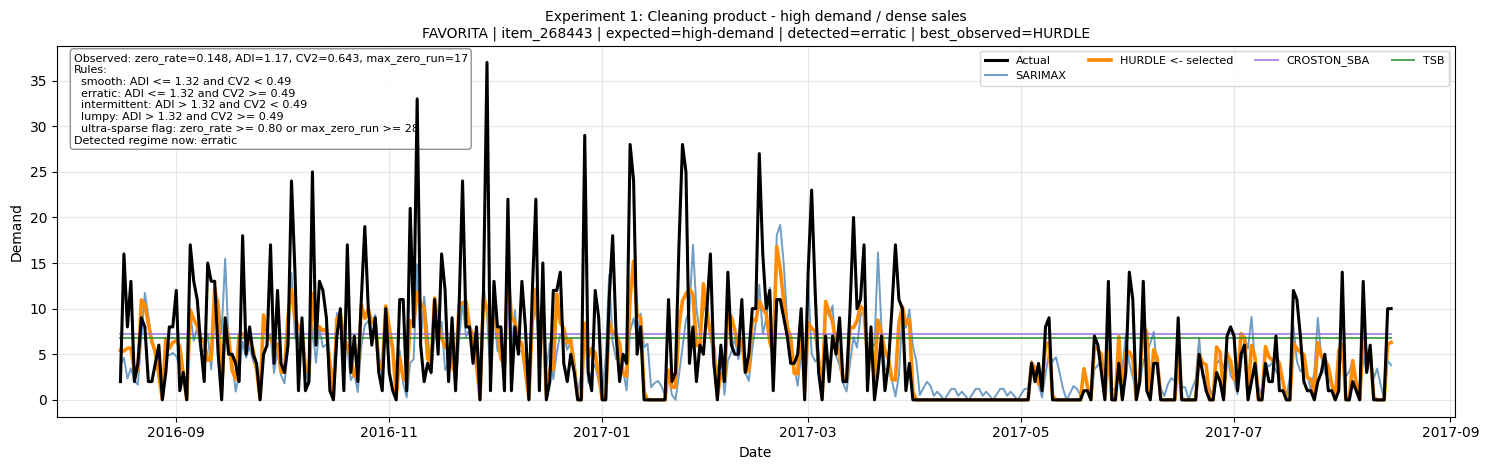

Story: Dense sales with relatively stable volume.
Best observed model: HURDLE
Why best observed: It is marked as the best observed model because it passed the behavioral guardrails and ranked highest on the PDR+VR+MAE composite score (MAE=2.9282, RMSE=4.8073, PDR=0.896, VR=0.580).
Engine recommendation: SARIMAX
Why engine recommended it: The product is in the smooth zero-rate zone (<0.30), so the paper guardrail routes it directly to SARIMAX.
Train stats -> zero_rate=0.148, ADI=1.17, CV2=0.643, max_zero_run=17


,model,included_in_plot,best_observed_for_case,engine_recommended,why_included,why_selected,engine_reason,detected_regime,zero_rate,ADI,CV2,MAE,RMSE
0,HURDLE,Yes,Yes,No,Separates sale occurrence from sale size; usef...,It is marked as the best observed model becaus...,Engine preferred SARIMAX (hard_zero_rate_guard...,erratic,0.148,1.17,0.643,2.9282,4.8073
1,SARIMAX,Yes,No,Yes,Baseline for dense or relatively stable demand...,Not selected: ranked below HURDLE on behaviora...,The product is in the smooth zero-rate zone (<...,erratic,0.148,1.17,0.643,3.6723,5.4912
2,TSB,Yes,No,No,Specialized model for intermittent demand with...,Not selected: ranked below HURDLE on behaviora...,Engine preferred SARIMAX (hard_zero_rate_guard...,erratic,0.148,1.17,0.643,5.3850,6.6152
3,CROSTON_SBA,Yes,No,No,Classic intermittent-demand baseline using Cro...,Not selected: ranked below HURDLE on behaviora...,Engine preferred SARIMAX (hard_zero_rate_guard...,erratic,0.148,1.17,0.643,5.5172,6.6968


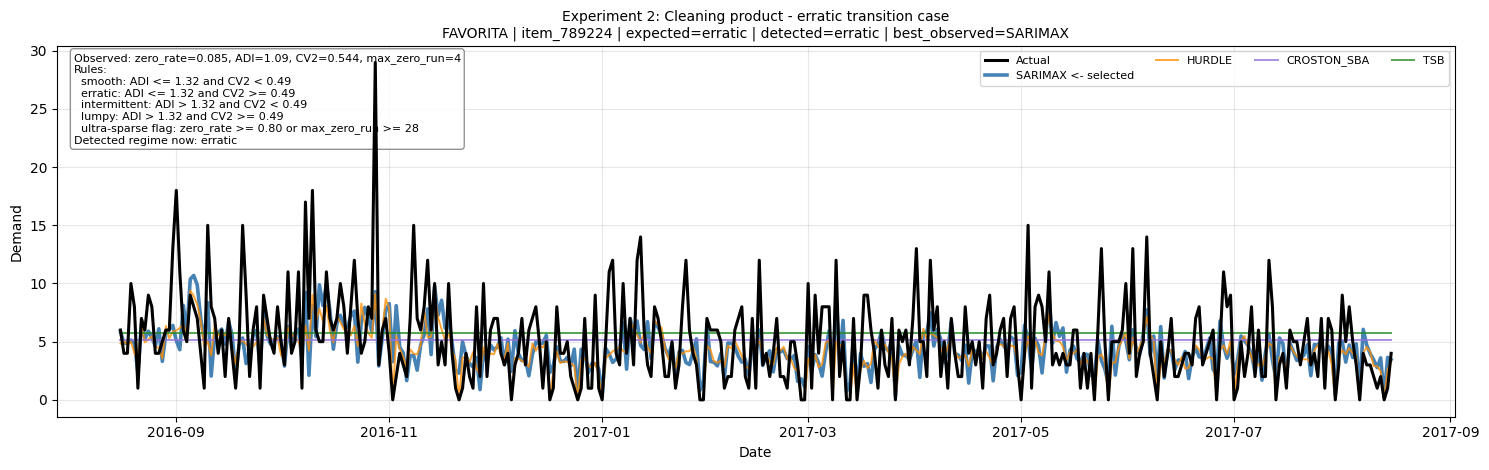

Story: Product still sells often, but with more variability.
Best observed model: SARIMAX
Why best observed: It is marked as the best observed model because it passed the behavioral guardrails and ranked highest on the PDR+VR+MAE composite score (MAE=2.3568, RMSE=3.2382, PDR=0.750, VR=0.498).
Engine recommendation: SARIMAX
Why engine recommended it: The product is in the smooth zero-rate zone (<0.30), so the paper guardrail routes it directly to SARIMAX.
Train stats -> zero_rate=0.085, ADI=1.09, CV2=0.544, max_zero_run=4


,model,included_in_plot,best_observed_for_case,engine_recommended,why_included,why_selected,engine_reason,detected_regime,zero_rate,ADI,CV2,MAE,RMSE
0,SARIMAX,Yes,Yes,Yes,Baseline for dense or relatively stable demand...,It is marked as the best observed model becaus...,The product is in the smooth zero-rate zone (<...,erratic,0.085,1.09,0.544,2.3568,3.2382
1,HURDLE,Yes,No,No,Separates sale occurrence from sale size; usef...,Not selected: ranked below SARIMAX on behavior...,Engine preferred SARIMAX (hard_zero_rate_guard...,erratic,0.085,1.09,0.544,2.2389,3.2287
2,CROSTON_SBA,Yes,No,No,Classic intermittent-demand baseline using Cro...,Not selected: ranked below SARIMAX on behavior...,Engine preferred SARIMAX (hard_zero_rate_guard...,erratic,0.085,1.09,0.544,2.8029,3.7157
3,TSB,Yes,No,No,Specialized model for intermittent demand with...,Not selected: ranked below SARIMAX on behavior...,Engine preferred SARIMAX (hard_zero_rate_guard...,erratic,0.085,1.09,0.544,2.9217,3.7615


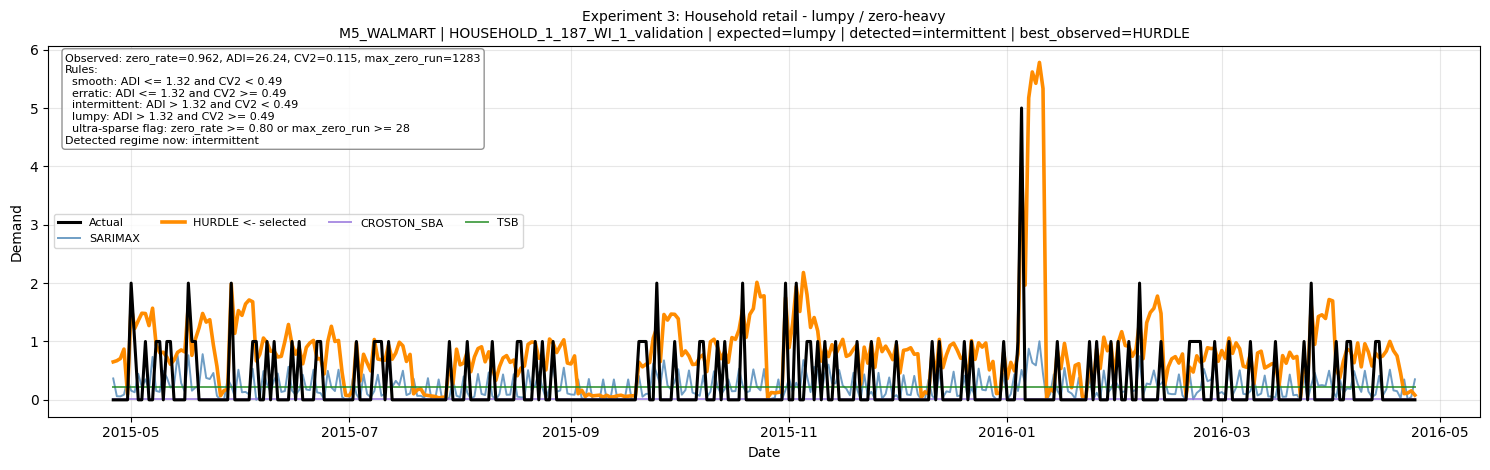

Story: Very sparse demand with strong zero concentration.
Best observed model: HURDLE
Why best observed: It is marked as the best observed model because it passed the behavioral guardrails and ranked highest on the PDR+VR+MAE composite score (MAE=0.6794, RMSE=0.9889, PDR=0.548, VR=1.318).
Engine recommendation: OBSOLESCENCE_FLAG
Why engine recommended it: OBSOLESCENCE_FLAG was selected by the regime engine and its guardrails.
Train stats -> zero_rate=0.962, ADI=26.24, CV2=0.115, max_zero_run=1283


,model,included_in_plot,best_observed_for_case,engine_recommended,why_included,why_selected,engine_reason,detected_regime,zero_rate,ADI,CV2,MAE,RMSE
0,HURDLE,Yes,Yes,No,Separates sale occurrence from sale size; usef...,It is marked as the best observed model becaus...,Engine preferred OBSOLESCENCE_FLAG (obsolescen...,intermittent,0.962,26.24,0.115,0.6794,0.9889
1,SARIMAX,Yes,No,No,Baseline for dense or relatively stable demand...,Not selected: ranked below HURDLE on behaviora...,Engine preferred OBSOLESCENCE_FLAG (obsolescen...,intermittent,0.962,26.24,0.115,0.3723,0.5561
2,CROSTON_SBA,Yes,No,No,Classic intermittent-demand baseline using Cro...,Not selected: ranked below HURDLE on behaviora...,Engine preferred OBSOLESCENCE_FLAG (obsolescen...,intermittent,0.962,26.24,0.115,0.2695,0.5966
3,TSB,Yes,No,No,Specialized model for intermittent demand with...,Not selected: ranked below HURDLE on behaviora...,Engine preferred OBSOLESCENCE_FLAG (obsolescen...,intermittent,0.962,26.24,0.115,0.3844,0.5458


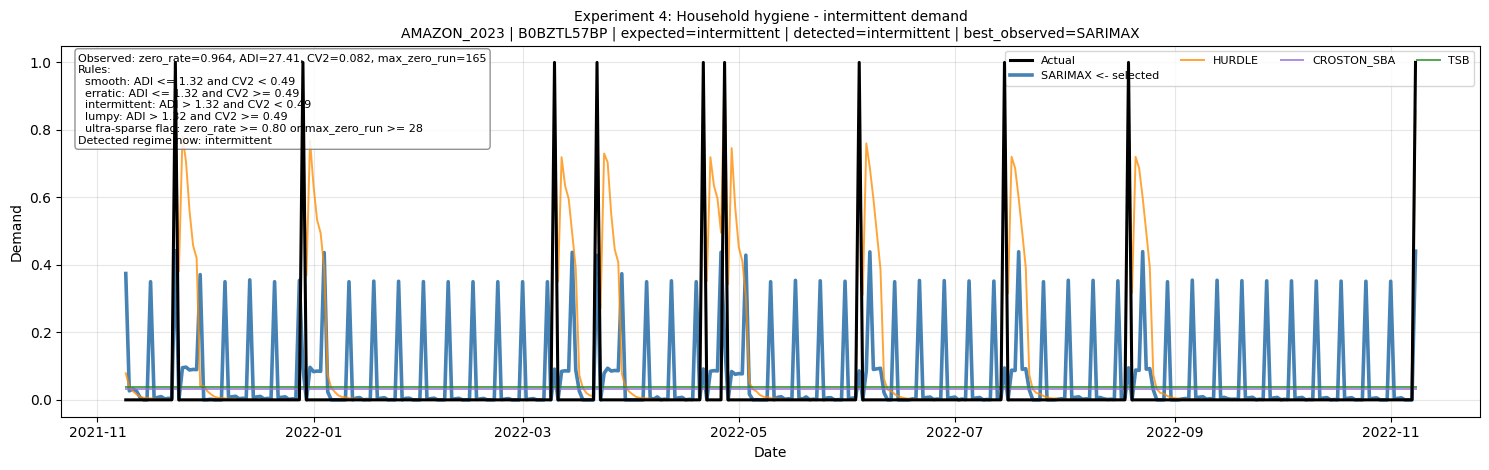

Story: Classic intermittent product with long zero runs and low non-zero variance.
Best observed model: SARIMAX
Why best observed: It is marked as the best observed model because it passed the behavioral guardrails and ranked highest on the PDR+VR+MAE composite score (MAE=0.0831, RMSE=0.1929, PDR=1.000, VR=0.786).
Engine recommendation: CROSTON_SBA
Why engine recommended it: CROSTON_SBA was selected by the regime engine and its guardrails.
Train stats -> zero_rate=0.964, ADI=27.41, CV2=0.082, max_zero_run=165


,model,included_in_plot,best_observed_for_case,engine_recommended,why_included,why_selected,engine_reason,detected_regime,zero_rate,ADI,CV2,MAE,RMSE
0,SARIMAX,Yes,Yes,No,Baseline for dense or relatively stable demand...,It is marked as the best observed model becaus...,Engine preferred CROSTON_SBA (intermittent_val...,intermittent,0.964,27.41,0.082,0.0831,0.1929
1,HURDLE,Yes,No,No,Separates sale occurrence from sale size; usef...,Not selected: ranked below SARIMAX on behavior...,Engine preferred CROSTON_SBA (intermittent_val...,intermittent,0.964,27.41,0.082,0.0843,0.2109
2,CROSTON_SBA,Yes,No,Yes,Classic intermittent-demand baseline using Cro...,Not selected: ranked below SARIMAX on behavior...,CROSTON_SBA was selected by the regime engine ...,intermittent,0.964,27.41,0.082,0.0574,0.1633
3,TSB,Yes,No,No,Specialized model for intermittent demand with...,Not selected: ranked below SARIMAX on behavior...,Engine preferred CROSTON_SBA (intermittent_val...,intermittent,0.964,27.41,0.082,0.0628,0.1636


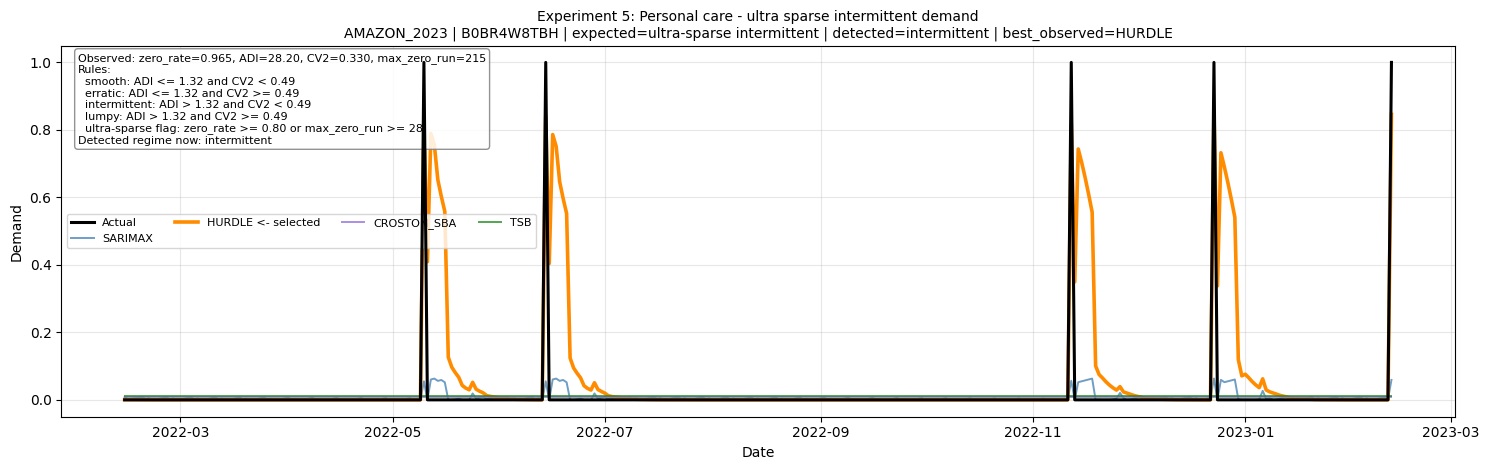

Story: Extreme zero-heavy product where weekly TSB is especially relevant.
Best observed model: HURDLE
Why best observed: It is marked as the best observed model because it passed the behavioral guardrails and ranked highest on the PDR+VR+MAE composite score (MAE=0.0494, RMSE=0.1625, PDR=1.000, VR=1.546).
Engine recommendation: TSB
Why engine recommended it: TSB was selected by the regime engine and its guardrails.
Train stats -> zero_rate=0.965, ADI=28.20, CV2=0.330, max_zero_run=215


,model,included_in_plot,best_observed_for_case,engine_recommended,why_included,why_selected,engine_reason,detected_regime,zero_rate,ADI,CV2,MAE,RMSE
0,HURDLE,Yes,Yes,No,Separates sale occurrence from sale size; usef...,It is marked as the best observed model becaus...,Engine preferred TSB (intermittent_validation_...,intermittent,0.965,28.2,0.33,0.0494,0.1625
1,SARIMAX,Yes,No,No,Baseline for dense or relatively stable demand...,Not selected: ranked below HURDLE on behaviora...,Engine preferred TSB (intermittent_validation_...,intermittent,0.965,28.2,0.33,0.0187,0.1112
2,CROSTON_SBA,Yes,No,No,Classic intermittent-demand baseline using Cro...,Not selected: ranked below HURDLE on behaviora...,Engine preferred TSB (intermittent_validation_...,intermittent,0.965,28.2,0.33,0.0217,0.1164
3,TSB,Yes,No,Yes,Specialized model for intermittent demand with...,Not selected: ranked below HURDLE on behaviora...,TSB was selected by the regime engine and its ...,intermittent,0.965,28.2,0.33,0.0257,0.1162


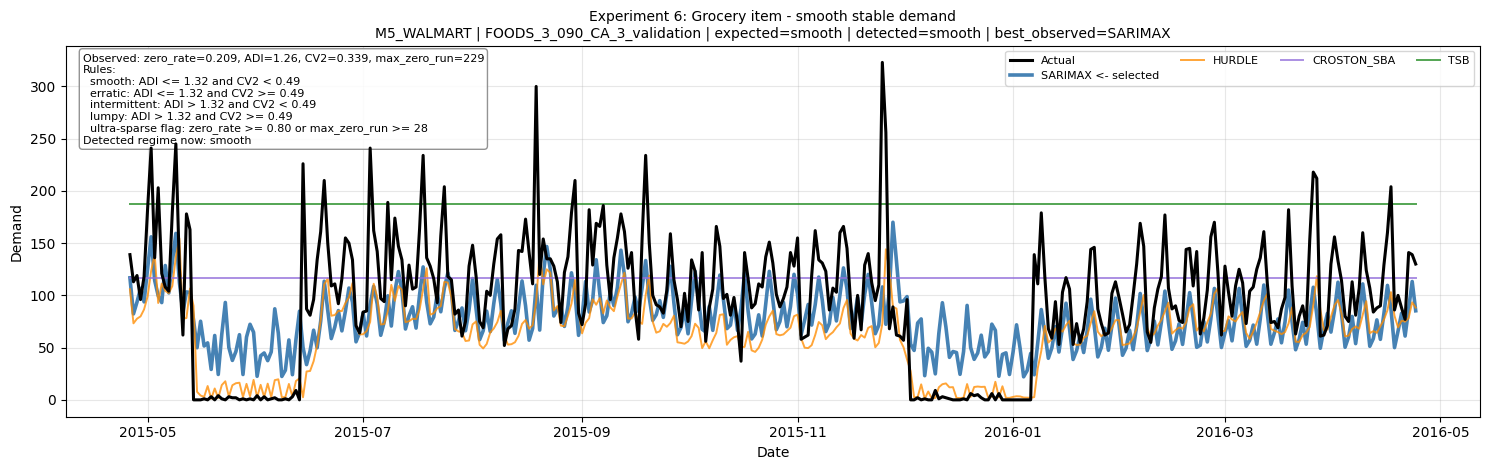

Story: High-frequency grocery product with consistent weekly pattern. SARIMAX is the correct model.
Best observed model: SARIMAX
Why best observed: It is marked as the best observed model because it passed the behavioral guardrails and ranked highest on the PDR+VR+MAE composite score (MAE=40.9109, RMSE=50.9730, PDR=1.000, VR=0.438).
Engine recommendation: SARIMAX
Why engine recommended it: The product is in the smooth zero-rate zone (<0.30), so the paper guardrail routes it directly to SARIMAX.
Train stats -> zero_rate=0.209, ADI=1.26, CV2=0.339, max_zero_run=229


,model,included_in_plot,best_observed_for_case,engine_recommended,why_included,why_selected,engine_reason,detected_regime,zero_rate,ADI,CV2,MAE,RMSE
0,SARIMAX,Yes,Yes,Yes,Baseline for dense or relatively stable demand...,It is marked as the best observed model becaus...,The product is in the smooth zero-rate zone (<...,smooth,0.209,1.26,0.339,40.9109,50.9730
1,HURDLE,Yes,No,No,Separates sale occurrence from sale size; usef...,Not selected: ranked below SARIMAX on behavior...,Engine preferred SARIMAX (hard_zero_rate_guard...,smooth,0.209,1.26,0.339,37.5142,51.9056
2,CROSTON_SBA,Yes,No,No,Classic intermittent-demand baseline using Cro...,Not selected: ranked below SARIMAX on behavior...,Engine preferred SARIMAX (hard_zero_rate_guard...,smooth,0.209,1.26,0.339,48.6851,63.2348
3,TSB,Yes,No,No,Specialized model for intermittent demand with...,Not selected: ranked below SARIMAX on behavior...,Engine preferred SARIMAX (hard_zero_rate_guard...,smooth,0.209,1.26,0.339,95.3986,109.1526


In [9]:
colors = {
    'SARIMAX': 'steelblue',
    'HURDLE': 'darkorange',
    'CROSTON_SBA': 'mediumpurple',
    'TSB': 'forestgreen',
}

for idx, case in enumerate(experiment_cases, start=1):
    key = (case['dataset'], case['series_id'])
    if key not in case_outputs:
        continue

    out = case_outputs[key]
    test_df = out['test_df']
    selected_model = out['best_observed_model']
    engine_model = out['engine_selected_model']
    selection_reason = out['engine_selection_info'].get('reason')
    sbc = out['sbc']

    # Plot all baseline forecasts, but highlight the best observed model.
    if not MATPLOTLIB_AVAILABLE:
        print('Plot skipped because matplotlib is blocked in this environment.')
    else:
        fig, ax = plt.subplots(figsize=(15, 4.8))
        ax.plot(test_df['date'], test_df['sales'].values, label='Actual', color='black', linewidth=2.2, zorder=10)

        for model_name, y_pred in out['predictions'].items():
            is_selected = model_name == selected_model
            ax.plot(
                test_df['date'],
                y_pred,
                label=model_name + (' <- selected' if is_selected else ''),
                color=colors.get(model_name, 'gray'),
                linewidth=2.6 if is_selected else 1.4,
                alpha=1.0 if is_selected else 0.78,
            )

        ax.set_title(
            f"Experiment {idx}: {case['semantic_product']}\n"
            f"{case['dataset']} | {case['series_id']} | expected={case['expected_regime']} | "
            f"detected={sbc['regime']} | best_observed={selected_model}",
            fontsize=10,
        )
        regime_box = regime_threshold_text(out['stats'], sbc['regime'], out['max_zero_run'])
        ax.text(
            0.012,
            0.98,
            regime_box,
            transform=ax.transAxes,
            va='top',
            ha='left',
            fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray'),
        )
        ax.set_xlabel('Date')
        ax.set_ylabel('Demand')
        ax.grid(alpha=0.3)  
        ax.legend(fontsize=8, ncols=4)
        plt.tight_layout()
        plt.show()

    print('Story:', case['target_story'])
    print('Best observed model:', selected_model)
    print('Why best observed:', observed_reason_text(selected_model, out['metrics']))
    print('Engine recommendation:', engine_model)
    print('Why engine recommended it:', selection_reason_text(selection_reason, engine_model))
    print(
        f"Train stats -> zero_rate={out['stats']['zero_rate']:.3f}, "
        f"ADI={out['stats']['ADI']:.2f}, CV2={out['stats']['CV2']:.3f}, "
        f"max_zero_run={out['max_zero_run']}"
    )
    display(out['comparison_table'])


## Global Summary

In [10]:

def expected_routing(zero_rate, sbc_regime):
    if zero_rate < 0.30:
        return 'SARIMAX'
    if zero_rate >= 0.70:
        return 'INTERMITTENT_MODEL'
    return 'BLEND_OR_EITHER'


def engine_in_correct_zone(row):
    zr = row['zero_rate']
    em = row['engine_model']
    if zr < 0.30:
        return em == 'SARIMAX'
    if zr >= 0.70:
        return em in {'HURDLE', 'TSB', 'CROSTON_SBA', 'OBSOLESCENCE_FLAG'}
    return True


summary_df = (
    results_df.sort_values(['dataset', 'series_id', 'mae'])
    .groupby(['dataset', 'series_id', 'semantic_product', 'expected_regime', 'sbc_regime', 'selected_model', 'engine_model'], as_index=False)
    .first()[['dataset', 'series_id', 'semantic_product', 'expected_regime', 'sbc_regime', 'selected_model', 'engine_model', 'model', 'mae', 'rmse', 'zero_rate', 'ADI', 'CV2', 'max_zero_run']]
    .rename(columns={'model': 'best_raw_mae_model'})
)
summary_df['expected_routing'] = summary_df.apply(
    lambda row: expected_routing(row['zero_rate'], row['sbc_regime']),
    axis=1,
)
summary_df['engine_correct'] = summary_df.apply(
    engine_in_correct_zone,
    axis=1,
).map({True: 'CORRECT', False: 'MISMATCH'})
summary_df['zero_rate_zone'] = summary_df['zero_rate'].apply(
    lambda zr: 'smooth (<0.30)' if zr < 0.30 else 'transitional (0.30-0.70)' if zr < 0.70 else 'intermittent (>=0.70)'
)
summary_df = summary_df[[
    'dataset', 'series_id', 'expected_regime', 'sbc_regime',
    'zero_rate_zone', 'selected_model', 'engine_model',
    'engine_correct', 'mae', 'rmse', 'zero_rate', 'ADI', 'CV2', 'max_zero_run',
    'expected_routing', 'semantic_product', 'best_raw_mae_model',
]]
summary_df

SPARSE_MODELS = {'HURDLE', 'TSB', 'CROSTON_SBA', 'OBSOLESCENCE_FLAG'}
n_correct = (summary_df['engine_correct'] == 'CORRECT').sum()
n_total = len(summary_df)
print(f'Engine routing accuracy: {n_correct}/{n_total} cases')
print()
smooth_cases = summary_df[summary_df['zero_rate'] < 0.30]
inter_cases = summary_df[summary_df['zero_rate'] >= 0.70]
print(
    f"Smooth zone (zero_rate<0.30):      "
    f"{(smooth_cases['engine_model'] == 'SARIMAX').sum()}/"
    f"{len(smooth_cases)} correct"
)
print(
    f"Intermittent zone (zero_rate>=0.70): "
    f"{inter_cases['engine_model'].isin(SPARSE_MODELS).sum()}/"
    f"{len(inter_cases)} correct"
)
print()
print("NOTE: 'engine_correct' means the engine routed to the")
print('right ZONE (smooth->SARIMAX, intermittent->any sparse')
print('model), not necessarily the exact best_observed model.')
print("This is the paper's actual routing claim.")
print()
print("Note: 'selected_model' = behavioral composite winner")
print("      'best_raw_mae_model' = lowest raw MAE only")
print("      These differ when PDR/VR guardrails override MAE.")
print()


Engine routing accuracy: 6/6 cases

Smooth zone (zero_rate<0.30):      3/3 correct
Intermittent zone (zero_rate>=0.70): 3/3 correct

NOTE: 'engine_correct' means the engine routed to the
right ZONE (smooth->SARIMAX, intermittent->any sparse
model), not necessarily the exact best_observed model.
This is the paper's actual routing claim.

Note: 'selected_model' = behavioral composite winner
      'best_raw_mae_model' = lowest raw MAE only
      These differ when PDR/VR guardrails override MAE.



In [11]:
out_dir = REPO_ROOT / 'reports' / 'paper_experiments'
out_dir.mkdir(parents=True, exist_ok=True)

results_path = out_dir / '26_five_case_model_results.csv'
summary_path = out_dir / '26_five_case_summary.csv'

results_df.to_csv(results_path, index=False)
summary_df.to_csv(summary_path, index=False)

print('Saved:', results_path)
print('Saved:', summary_path)


Saved: C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\paper_experiments\26_five_case_model_results.csv
Saved: C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\paper_experiments\26_five_case_summary.csv
